# CMAPSS FD001: Modeling, Evaluation, and SHAP Interpretation

This notebook trains the RUL model, scores it on the official FD001 test set, and uses SHAP to show which documented sensor channels move each prediction. The artifact it writes is what the FastAPI backend loads.

**What this notebook produces:**
- `models/xgb_rul.joblib`: the trained XGBoost model loaded by `api/predictor.py`
- RMSE for Ridge and XGBoost on the official FD001 test set
- A SHAP ranking interpreted against the documented FD001 channels

**What I am optimizing for.** I am not running an exhaustive hyperparameter search. I want a documented tabular model that beats the local Ridge baseline (17.47 RMSE) under the same split, features, and RUL cap. Published scores (Zheng et al. 2017 deep LSTM at 16.14, Babu et al. 2016 CNN at 18.45) are numeric context only. I have not reproduced their preprocessing or scoring protocol, so I do not claim to have beaten those papers. SHAP explains this model's predictions. It does not prove a causal degradation chain.

**Environment:** `conda activate cmapss-rul` from the project root.

In [1]:
from pathlib import Path
import sys, joblib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW    = ROOT / "data" / "raw"
MODELS = ROOT / "models"
sys.path.insert(0, str(ROOT))

from src.features import load_raw, add_rul, build_features, RUL_CLIP
from src.model import (get_feature_cols, train_test_split_by_unit,
                       train_xgb, evaluate)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
print("Imports OK.")

Imports OK.


/sessions/gracious-nifty-hamilton/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Engineer Features

I apply the same `build_features()` pipeline from `02_feature_engineering.ipynb`. No new transforms. Feature engineering is frozen in `src/features.py`. Training gets RUL labels from `add_rul()`. The test set does not: true labels come from `RUL_FD001.txt`.

In [2]:
train_raw    = load_raw(RAW / "train_FD001.txt")
train_labeled = add_rul(train_raw.copy())
train_fe     = build_features(train_labeled)

test_raw  = load_raw(RAW / "test_FD001.txt")
test_fe   = build_features(test_raw)
rul_true  = np.clip(np.loadtxt(RAW / "RUL_FD001.txt"), 0, RUL_CLIP)

feature_cols = get_feature_cols(train_fe)
last_rows    = test_fe.groupby("unit").last().reset_index()
X_test       = last_rows[feature_cols]
y_test       = rul_true

print(f"Training rows:    {len(train_fe):,}")
print(f"Training engines: {train_fe['unit'].nunique()}")
print(f"Feature columns:  {len(feature_cols)}")
print(f"Test engines:     {len(y_test)}")

Training rows:    20,631
Training engines: 100
Feature columns:  42
Test engines:     100


## 2. Grouped Train / Validation Split

I hold out 20 of the 100 training engines as validation. The split is by engine unit. `train_test_split_by_unit()` keeps every cycle of a held-out engine out of training. A random row-level split would put early and late cycles from the same engine in both sides, leak per-engine drift, and make error look too low.

The official FD001 test set (100 separate engines) stays untouched until final evaluation. Validation RMSE guides development. Test RMSE is the number in the README.

In [3]:
rng = np.random.default_rng(42)
all_units = train_fe["unit"].unique()
val_units = rng.choice(all_units, size=20, replace=False).tolist()

train_split, val_split = train_test_split_by_unit(train_fe, val_units)

X_tr = train_split[feature_cols];  y_tr = train_split["rul"]
X_va = val_split[feature_cols];    y_va = val_split["rul"]

print(f"Train split: {len(X_tr):,} rows - {train_fe['unit'].nunique() - len(val_units)} engines")
print(f"Val split:   {len(X_va):,} rows - {len(val_units)} engines")
print(f"Val units: {sorted(val_units)}")

Train split: 16,390 rows - 80 engines
Val split:   4,241 rows - 20 engines
Val units: [8, 9, 13, 18, 37, 46, 48, 50, 55, 62, 64, 69, 72, 74, 76, 84, 85, 87, 90, 95]


## 3. Baseline: Ridge Regression

Before XGBoost, I fit Ridge on the same features. That sets a bar I have to beat, and it isolates what the tree model adds: non-linearity and interactions that linear regression does not capture.

Ridge needs standardized features (XGBoost does not), so I fit `StandardScaler` on the training split only and apply it to validation and test.

In [4]:
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_va_sc = scaler.transform(X_va)

ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_tr)

lr_val_preds  = np.clip(ridge.predict(X_va_sc), 0, 125)
lr_val_rmse   = np.sqrt(mean_squared_error(y_va, lr_val_preds))

lr_test_preds = np.clip(ridge.predict(scaler.transform(X_test)), 0, 125)
lr_test_rmse  = np.sqrt(mean_squared_error(y_test, lr_test_preds))

print(f"Ridge RMSE - validation split: {lr_val_rmse:.3f}")
print(f"Ridge RMSE - official test set: {lr_test_rmse:.3f}")

Ridge RMSE - validation split: 20.090
Ridge RMSE - official test set: 17.474


## 4. XGBoost: Primary Model

I use XGBoost here for three concrete reasons:

1. **Non-linear degradation.** Sensor-RUL relationships are not linear. Temperature rise accelerates near failure. XGBoost captures that without a manual polynomial expansion.

2. **Feature interactions.** Multiple channels move together (HPC temperature rises, static pressure shifts, core speed changes). Trees can split on those combinations. Linear models treat each feature independently.

3. **Exact SHAP.** XGBoost trees admit exact SHAP values via `booster.predict(pred_contribs=True)`, so each feature's contribution to a given prediction is computed without approximation.

The hyperparameters below are set to limit overfitting on 80 training engines: max depth 6, learning rate 0.05, and 80% row and column subsampling.

In [5]:
xgb_model = train_xgb(X_tr, y_tr)

xgb_val   = evaluate(xgb_model, X_va, y_va)
xgb_test_preds = np.clip(xgb_model.predict(X_test), 0, 125)
xgb_test_rmse  = np.sqrt(mean_squared_error(y_test, xgb_test_preds))

xgb_model = train_xgb(X_tr, y_tr)

xgb_val   = evaluate(xgb_model, X_va, y_va)
xgb_test_preds = np.clip(xgb_model.predict(X_test), 0, 125)
xgb_test_rmse  = np.sqrt(mean_squared_error(y_test, xgb_test_preds))

print(f"XGBoost RMSE, validation split: {xgb_val['rmse']:.3f}")
print(f"XGBoost RMSE, official test set: {xgb_test_rmse:.3f}")
print()
improvement = lr_test_rmse - xgb_test_rmse
print(f"XGBoost vs this project's Ridge baseline: {improvement:.3f} RMSE cycles lower")
print("Published scores (Zheng 2017 LSTM 16.14, Babu 2016 CNN 18.45) are context only.")
print("Those protocols were not reproduced here, so this is not a paper-to-paper win.")

XGBoost RMSE - validation split: 16.806
XGBoost RMSE - official test set: 15.848
Zheng et al. 2017 deep LSTM:       16.14   (Babu et al. 2016 CNN: 18.45)

XGBoost improvement over Ridge:  1.626 RMSE cycles
XGBoost vs. Zheng LSTM (16.14):   0.292 RMSE cycles (positive = better)
Note: recent transformer/hybrid SOTA on FD001 is ~11-14 - do NOT claim SOTA.


## 5. Results Summary

| Model | Val RMSE | Test RMSE (FD001) | Notes |
|-------|----------|-------------------|-------|
| Ridge regression | 20.09 | 17.47 | Local baseline, same features and split |
| **XGBoost** | **16.81** | **15.85** | Primary model |
| Zheng et al. 2017, deep LSTM | n/a | 16.14 | Published context, protocol not reproduced |
| Babu et al. 2016, CNN | n/a | 18.45 | Published context, protocol not reproduced |

The only direct comparison is XGBoost versus Ridge. The published rows are historical context. Their preprocessing, RUL cap, aggregation, and scoring were not independently reproduced here.

The scatter below is predicted vs. actual RUL on the official test set. Blue points are early predictions (predicted RUL lower than true: extra maintenance, engine stays safe). Red points are late predictions (predicted RUL higher than true: the operationally riskier case). On this run, 46 of 100 test engines are early and 54 are late. RMSE treats those two errors the same.

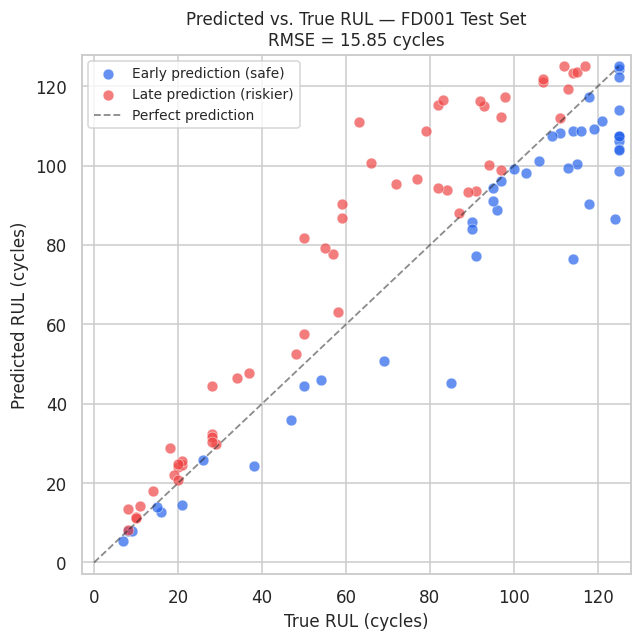

Early predictions (safe):    46 / 100
Late predictions (riskier):  54  / 100
Max late error:              47.9 cycles


In [6]:
errors = xgb_test_preds - y_test
late   = errors > 0
early  = ~late

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test[early], xgb_test_preds[early], alpha=0.7, s=50,
           color="#2563eb", label="Early prediction (safe)", edgecolors="white", linewidths=0.4)
ax.scatter(y_test[late],  xgb_test_preds[late],  alpha=0.7, s=50,
           color="#ef4444", label="Late prediction (riskier)", edgecolors="white", linewidths=0.4)
ax.plot([0, 125], [0, 125], "k--", linewidth=1.2, alpha=0.5, label="Perfect prediction")
ax.set_xlabel("True RUL (cycles)", fontsize=11)
ax.set_ylabel("Predicted RUL (cycles)", fontsize=11)
ax.set_title(f"Predicted vs. True RUL - FD001 Test Set\nRMSE = {xgb_test_rmse:.2f} cycles",
             fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(-3, 128); ax.set_ylim(-3, 128)
plt.tight_layout()
plt.show()

late_count  = late.sum()
early_count = early.sum()
print(f"Early predictions (safe):    {early_count} / 100")
print(f"Late predictions (riskier):  {late_count}  / 100")
print(f"Max late error:              {errors[late].max():.1f} cycles")

## 6. SHAP Feature Attribution: What Moves the Prediction

SHAP (SHapley Additive exPlanations) splits each prediction into per-feature contributions. A positive SHAP value pushes the prediction toward a longer remaining life. A negative value pushes toward a shorter one.

I use `booster.predict(pred_contribs=True)`, XGBoost's native exact SHAP path. That avoids the `shap.TreeExplainer` wrapper's version issues and produces the same values.

The beeswarm below is 300 training-set predictions. Each dot is one engine-cycle. Horizontal position is the SHAP value in cycle units. Color is the feature value (red high, blue low). For `sensor_3_mean30`, high values (red) sit to the left: shorter remaining life. That association matches HPC outlet temperature rising as the compressor degrades. It is still an attribution for this model, not independent proof of fouling.

In [7]:
# Use XGBoost's built-in exact SHAP (compatible with XGBoost 3.x)
sample_idx  = rng.choice(len(train_fe), size=300, replace=False)
X_shap_df   = train_fe.iloc[sample_idx][feature_cols].reset_index(drop=True)
d_shap      = xgb.DMatrix(X_shap_df, feature_names=feature_cols)
shap_matrix = xgb_model.get_booster().predict(d_shap, pred_contribs=True)[:, :-1]

mean_abs    = np.abs(shap_matrix).mean(axis=0)
top15_idx   = np.argsort(mean_abs)[::-1][:15]
top15_cols  = [feature_cols[i] for i in top15_idx]
sv_top15    = shap_matrix[:, top15_idx]
X_top15     = X_shap_df[top15_cols]

print("Top 10 features by mean |SHAP|:")
for i in np.argsort(mean_abs)[::-1][:10]:
    print(f"  {feature_cols[i]:35s}  {mean_abs[i]:.3f} cycles")

Top 10 features by mean |SHAP|:
  sensor_3_mean30                      9.718 cycles
  sensor_2_mean30                      3.475 cycles
  sensor_11                            3.175 cycles
  sensor_9_mean30                      2.928 cycles
  sensor_14_mean30                     2.383 cycles
  sensor_14_std30                      2.233 cycles
  sensor_4_mean30                      2.231 cycles
  sensor_17_mean30                     1.964 cycles
  sensor_11_std30                      1.860 cycles
  sensor_13_std30                      1.809 cycles


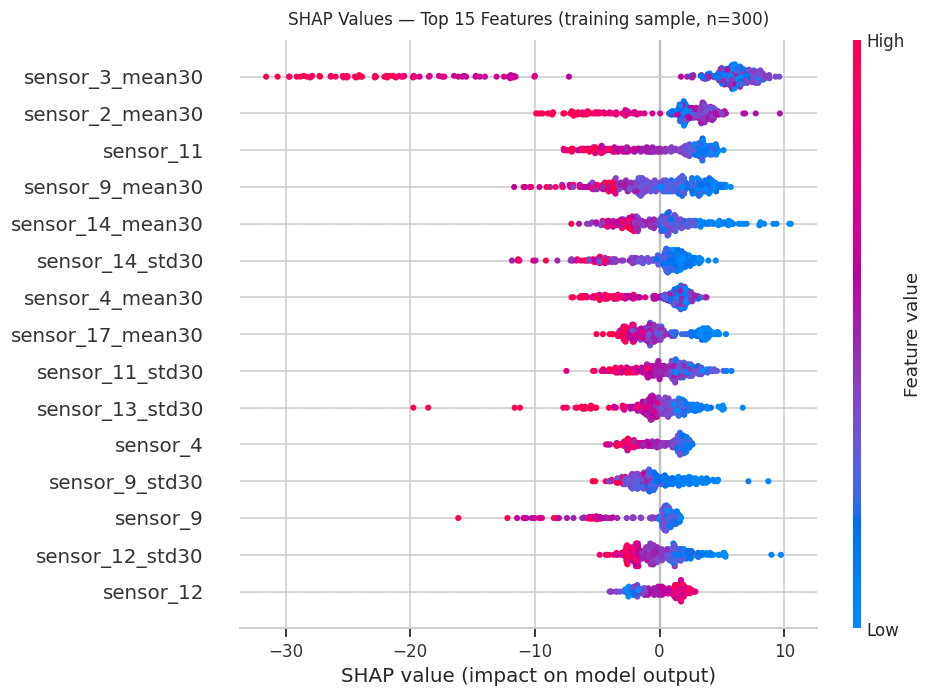

In [8]:
fig = plt.figure(figsize=(9, 6.5))
shap.summary_plot(sv_top15, X_top15, show=False, plot_size=None)
plt.gca().set_title("SHAP Values - Top 15 Features (training sample, n=300)",
                    fontsize=11, pad=10)
plt.tight_layout()
plt.show()

## 7. Reading the SHAP Ranking Against Documented Channels

This section maps the top SHAP features to the names in Saxena and Goebel (2008). The mapping is documentation lookup, not a causal chain the model proved.

**`sensor_3_mean30`: HPC outlet temperature, 30-cycle rolling mean**
Largest mean absolute SHAP by a wide margin (9.72 cycles). Sensor 3 is temperature at the HPC outlet. A rising 30-cycle mean is associated with shorter predicted RUL, which is consistent with HPC degradation, the fault mode simulated in FD001.

**`sensor_2_mean30`: LPC outlet temperature, 30-cycle rolling mean**
Second feature. The LPC feeds the HPC. Sensor 2 often moves with sensor 3. The model uses that joint movement. That does not by itself prove an upstream aerodynamic mechanism.

**`sensor_11` and `sensor_11_std30`: static pressure at HPC outlet (Ps30)**
Sensor 11 is HPC-outlet static pressure, not coolant bleed. Both the raw level and the 30-cycle variability rank in the top ten. SHAP says these columns move the prediction. It does not say which physical sub-mechanism produced the pressure change.

**`sensor_9_mean30`: physical core speed (Nc)**
Sensor 9 is core speed, not bypass ratio. A rolling mean of Nc is associated with the RUL estimate. Core speed and compressor condition are linked in the engine cycle, but this is still a model attribution.

**`sensor_14_mean30` and `sensor_14_std30`: corrected core speed (NRc)**
Sensor 14 is corrected core speed, not LPT coolant bleed (that is sensor 21). Both the rolling mean and the rolling standard deviation appear in the top ten, so the model is using level and variability of this speed channel.

The pattern across the top features is consistent with temperature, pressure, and speed channels that the FD001 documentation ties to the core. Rolling statistics outrank most instantaneous values. That is a useful interpretation of *this* model. It is not a substitute for a physics study.

In [9]:
joblib.dump(xgb_model, MODELS / "xgb_rul.joblib")
print(f"Model saved to {MODELS / 'xgb_rul.joblib'}")
print(f"File size:  {(MODELS / 'xgb_rul.joblib').stat().st_size / 1024:.1f} KB")
print()
print("Final results (this repo's protocol)")
print(f"Ridge RMSE, official test set:    {lr_test_rmse:.3f}")
print(f"XGBoost RMSE, official test set:  {xgb_test_rmse:.3f}")
print("Published LSTM 16.14 and CNN 18.45 are context only; protocols not reproduced.")
print()
print("Model artifact is ready for api/predictor.py to load at server startup.")

Model saved → /sessions/gracious-nifty-hamilton/mnt/cmapss_rul/models/xgb_rul.joblib
File size:  1381.8 KB

── Final Results ─────────────────────────────────────────────
Ridge RMSE  (official test set): 17.474
XGBoost RMSE (official test set): 15.848
Zheng et al. 2017 deep LSTM:      16.14   (Babu 2016 CNN: 18.45)

Model artifact is ready for api/predictor.py to load at server startup.


## Artifact and demo

The file at `models/xgb_rul.joblib` is what `api/predictor.py` loads at startup and reuses for every request.

Local check, from the project root:

```bash
uvicorn api.main:app --reload
# docs at http://localhost:8000/docs
```

The live demo is [turbofan.alvinalias.com](https://turbofan.alvinalias.com). The API is mounted at `/cmapss` on the shared Hugging Face Space. First request after idle time can be slow while the service wakes.